# Project

## Loading the dataset

In [1]:
import glob
from typing import Tuple
import polars as pl
import os

In [2]:
DATA_ROOT = "data"

In [3]:
def get_labels_from_filename(filename: str) -> Tuple[str, str, bool]:
    if "Benign" in filename:
        return "Benign", "Benign", False

    if "ARP_Spoofing" in filename:
        return "ARP_Spoofing", "Spoofing", True

    if "Recon" in filename:
        category = "Recon"
        if "Recon-Ping_Sweep" in filename:
            return "Ping_Sweep", category, True
        if "Recon-VulScan" in filename:
            return "VulScan", category, True
        if "Recon-OS_Scan" in filename:
            return "OS_Scan", category, True
        if "Recon-Port_Scan" in filename:
            return "Port_Scan", category, True

    if "MQTT" in filename:
        category = "MQTT"
        if "MQTT-Malformed_Data" in filename:
            return "Malformed_Data", category, True
        if "MQTT-DoS-Connect_Flood" in filename:
            return "DoS_Connect_Flood", category, True
        if "MQTT-DDoS-Publish_Flood" in filename:
            return "DDoS_Publish_Flood", category, True
        if "MQTT-DoS-Publish_Flood" in filename:
            return "DoS_Publish Flood", category, True
        if "MQTT-DDoS-Connect_Flood" in filename:
            return "DDoS_Connect_Flood", category, True

    if "TCP_IP-DoS" in filename:
        category = "DoS"
        if "TCP_IP-DoS-TCP" in filename:
            return "DoS_TCP", category, True
        if "TCP_IP-DoS-ICMP" in filename:
            return "DoS_ICMP", category, True
        if "TCP_IP-DoS-SYN" in filename:
            return "DoS_SYN", category, True
        if "TCP_IP-DoS-UDP" in filename:
            return "DoS_UDP", category, True

    if "TCP_IP-DDoS" in filename:
        category = "DDoS"
        if "TCP_IP-DDoS-SYN" in filename:
            return "DDoS_SYN", category, True
        if "TCP_IP-DDoS-TCP" in filename:
            return "DDoS_TCP", category, True
        if "TCP_IP-DDoS-ICMP" in filename:
            return "DDoS_ICMP", category, True
        if "TCP_IP-DDoS-UDP" in filename:
            return "DDoS_UDP", category, True

    return "", "", False  # Should never reach here with correct dataset format

In [4]:
def combine_dataset_files(root: str, save_name: str = "combined_dataset") -> None:
    path = os.path.join(root,"*","*.csv")
    files = glob.glob(path, recursive=True)
    combined_dir = os.path.join(root, "combined")
    out_path = os.path.join(combined_dir, f"{save_name}.parquet")
    os.makedirs(combined_dir, exist_ok=True)

    frames = []
    with pl.StringCache():
        for file in files:
            name, category, attack = get_labels_from_filename(file)

            lf = pl.scan_csv(file)

            lf = lf.with_columns(
                [
                    pl.lit(name).alias("Name").cast(pl.Categorical),
                    pl.lit(category).alias("Category").cast(pl.Categorical),
                    pl.lit(attack).alias("Attack"),
                ]
            )

            frames.append(lf)

        combined_lf = pl.concat(frames)
        combined_lf.sink_parquet(out_path)

In [5]:
def load_dataset(save_name: str) -> pl.DataFrame:
    path = os.path.join(DATA_ROOT, "combined", f"{save_name}.parquet")
    if not os.path.exists(path):
        combine_dataset_files(DATA_ROOT, save_name)
    df = pl.read_parquet(path)
    return df

In [6]:
df = load_dataset("combined_dataset").with_columns(pl.col(pl.Float64).cast(pl.Float32)) # reducing memory usage

## Exploratory Data Analysis

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [8]:
%matplotlib inline
sns.set_theme(style="darkgrid", context="paper", palette="bright")

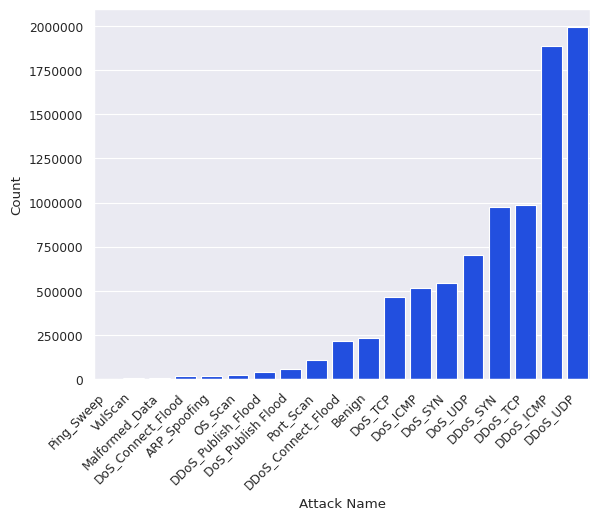

In [9]:
def plot_attack_counts(data):
    attack_counts = data.group_by("Name").len().sort("len", descending=False)
    attack_counts = attack_counts.to_pandas()
    fig, ax = plt.subplots()
    sns.barplot(x=attack_counts["Name"], y=attack_counts["len"], ax=ax)
    plt.ticklabel_format(style="plain", axis="y")
    plt.xlabel("Attack Name")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
plot_attack_counts(df)

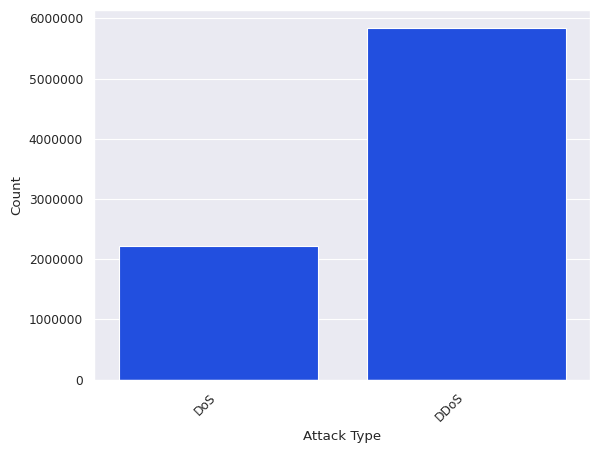

In [10]:
def plot_ddos_dos_bar(data):
    ddos_dos_counts = (
        data.filter(pl.col("Category").is_in(["DDoS", "DoS"]))
        .group_by("Category")
        .len()
        .sort("len", descending=False)
    )
    plot_data = ddos_dos_counts.to_pandas()
    plot_data.columns = ["Attack Type", "Count"]

    fig, ax = plt.subplots()
    sns.barplot(x=plot_data["Attack Type"], y=plot_data["Count"], ax=ax)
    plt.ticklabel_format(style="plain", axis="y")
    plt.xlabel("Attack Type")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
plot_ddos_dos_bar(df)

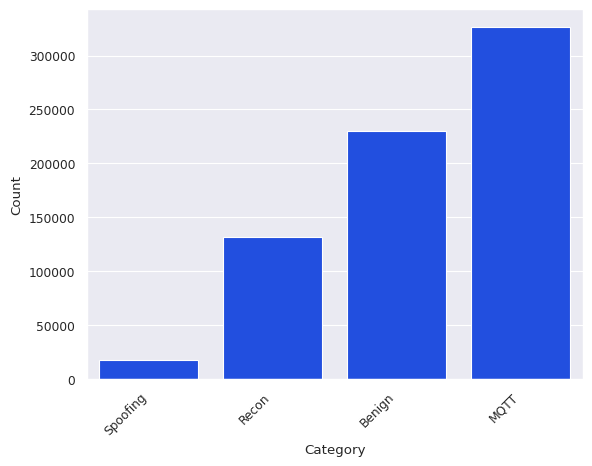

In [11]:
def plot_categories_no_ddos_dos(data):
    included_categories = ["MQTT", "Spoofing", "Recon", "Benign"]
    category_counts = (
        data.filter(pl.col("Category").is_in(included_categories))
        .group_by("Category")
        .len()
        .sort("len", descending=False)
    )
    category_counts = category_counts.to_pandas()

    fig, ax = plt.subplots()
    sns.barplot(x=category_counts["Category"], y=category_counts["len"], ax=ax)
    plt.ticklabel_format(style="plain", axis="y")
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
plot_categories_no_ddos_dos(df)

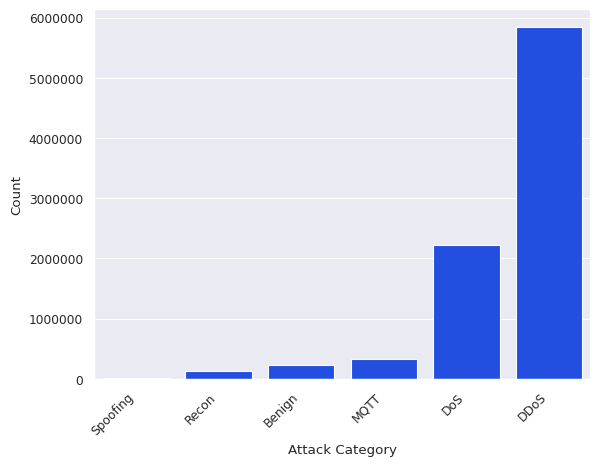

In [12]:
def plot_all_attack_categories_bar(data):
    category_counts = data.group_by("Category").len().sort("len", descending=False)
    category_counts = category_counts.to_pandas()
    fig, ax = plt.subplots()
    sns.barplot(x=category_counts["Category"], y=category_counts["len"], ax=ax)
    plt.ticklabel_format(style="plain", axis="y")
    plt.xlabel("Attack Category")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
plot_all_attack_categories_bar(df)

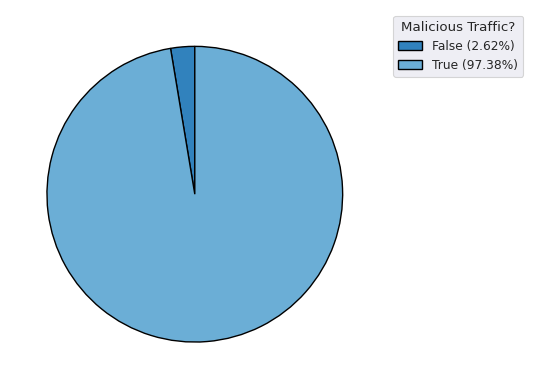

In [13]:
def plot_attack_benign_pie(data):
    attack_counts = data.group_by("Attack").len().sort("len", descending=False)
    attack_counts = attack_counts.to_pandas()
    attack_counts.columns = ["Attack", "Count"]

    attack_counts = attack_counts.set_index("Attack")["Count"]
    total_count = attack_counts.sum()
    percentages = (attack_counts / total_count) * 100
    slices = attack_counts.values
    labels = attack_counts.index

    colours = sns.color_palette("tab20c", len(labels))

    fig, ax = plt.subplots()
    plt.pie(
        slices,  # pyright: ignore[reportArgumentType]
        colors=colours,  # pyright: ignore[reportArgumentType]
        wedgeprops=dict(edgecolor="black", linewidth=1),
        textprops=dict(color="white", fontsize=10),
        startangle=90,
    )

    legend_labels = [
        f"{label} ({percentage:.2f}%)"
        for label, percentage in zip(labels, percentages)
    ]
    ax.legend(
        legend_labels,
        title="Malicious Traffic?",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    plt.gca().set_aspect("equal")
plot_attack_benign_pie(df)

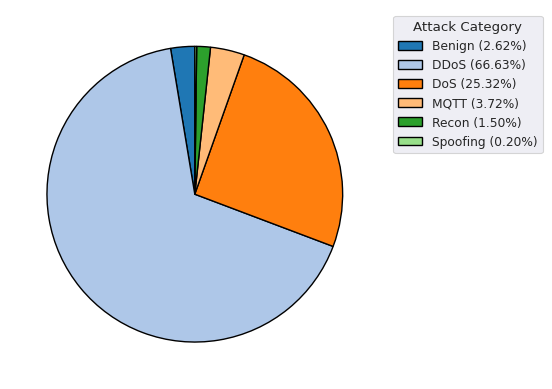

In [14]:
def plot_breakdown_pie(data):
    target_column = "Category"
    attack_counts = data.group_by(target_column).len().sort(target_column)
    attack_counts = attack_counts.to_pandas()
    attack_counts.columns = [target_column, "Count"]

    attack_counts = attack_counts.set_index(target_column)["Count"]
    total_count = attack_counts.sum()
    percentages = (attack_counts / total_count) * 100
    slices = attack_counts.values
    labels = attack_counts.index

    fig, ax = plt.subplots()
    colours = sns.color_palette("tab20", len(labels))
    plt.pie(
        slices,  # pyright: ignore[reportArgumentType]
        wedgeprops=dict(edgecolor="black", linewidth=1),
        textprops=dict(color="white", fontsize=10),
        startangle=90,
        colors=colours,
    )

    legend_labels = [
        f"{label} ({percentage:.2f}%)"
        for label, percentage in zip(labels, percentages)
    ]
    ax.legend(
        legend_labels,
        title=f"Attack {target_column}",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    plt.gca().set_aspect("equal")
    
plot_breakdown_pie(df)

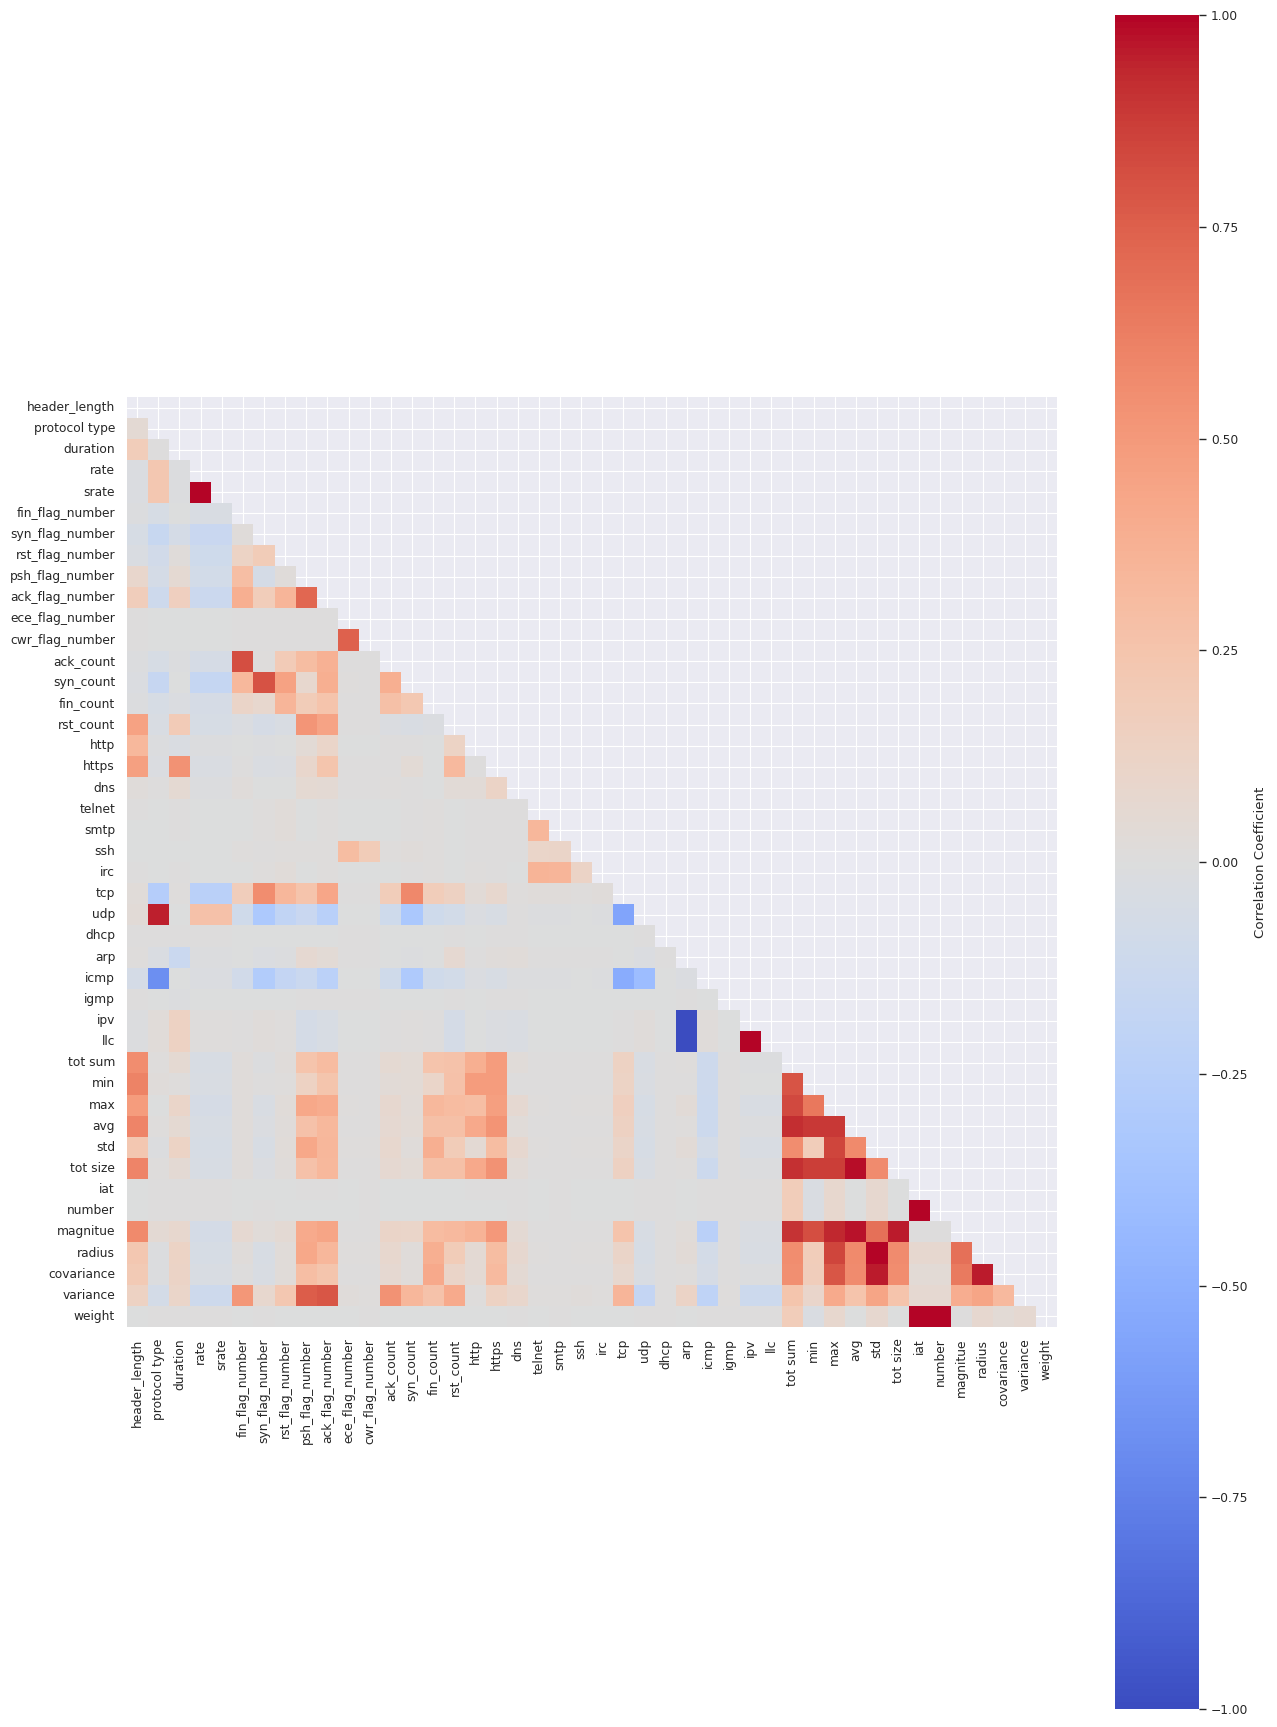

In [15]:
def plot_correlation_heatmap(data):
    numeric_data = data.select(
        pl.exclude("Attack", "Category", "Name").name.map(lambda name: name.lower())
    )

    std_devs = numeric_data.select(pl.all().std())
    zer_var_cols = [col for col in std_devs.columns if std_devs[col][0] == 0]
    numeric_data = numeric_data.drop(zer_var_cols)

    corr = numeric_data.corr()
    corr_labels = corr.columns
    corr = corr.to_numpy()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(15, len(corr_labels) // 2))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        square=True,
        ax=ax,
        mask=mask,
        cbar_kws=dict(label="Correlation Coefficient"),
        xticklabels=corr_labels,
        yticklabels=corr_labels,
    )
plot_correlation_heatmap(df)

## Preprocessing

In [16]:
from imblearn.under_sampling import RandomUnderSampler

In [17]:
df = df.drop(["Name", "Attack"])
X = df.drop("Category").to_numpy()
y = df.select("Category").to_series().to_numpy()

### Undersampling Traffic Categories

In [18]:
sampling_strategy={"DDoS": 300_000, "DoS": 300_000}

In [19]:
rus = RandomUnderSampler(
        sampling_strategy=sampling_strategy, random_state=0
    )
X_resampled, y_resampled = rus.fit_resample(X, y)
df_resampled = pl.DataFrame(X_resampled, schema=df.drop("Category").columns)
df_resampled = df_resampled.with_columns(pl.Series("Category", y_resampled))

In [20]:
del df, X, y # Clearing some memory

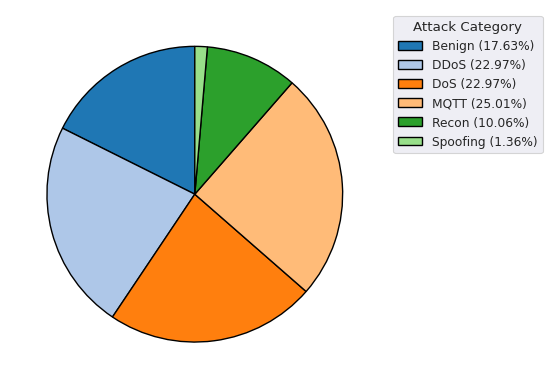

In [21]:
def plot_breakdown_pie_resampled(data):
    target_column = "Category"
    attack_counts = data.group_by(target_column).len().sort(target_column)
    attack_counts = attack_counts.to_pandas()
    attack_counts.columns = [target_column, "Count"]

    attack_counts = attack_counts.set_index(target_column)["Count"]
    total_count = attack_counts.sum()
    percentages = (attack_counts / total_count) * 100
    slices = attack_counts.values
    labels = attack_counts.index

    fig, ax = plt.subplots()
    colours = sns.color_palette("tab20", len(labels))
    plt.pie(
        slices,  # pyright: ignore[reportArgumentType]
        wedgeprops=dict(edgecolor="black", linewidth=1),
        textprops=dict(color="white", fontsize=10),
        startangle=90,
        colors=colours,
    )

    legend_labels = [
        f"{label} ({percentage:.2f}%)"
        for label, percentage in zip(labels, percentages)
    ]
    ax.legend(
        legend_labels,
        title=f"Attack {target_column}",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    plt.gca().set_aspect("equal")
plot_breakdown_pie_resampled(df_resampled)

In [ ]:
plt.close("all")
del rus, sampling_strategy

In [ ]:
del df_resampled, X_resampled, y_resampled